---

# Principal Component Analysis (PCA)

**Principal Component Analysis** (PCA) is an unsupervised machine learning technique used for multidimensionality reduction. 

The idea is to project data points onto its most important components to get a dataset which has fewer features, but maintains its variance. Thus, we use it to remove redundant and correlated data to keep only the most significant features.

- The first component minimizes the variance of the projected data.
- The second component is orthogonal to the first component, and the next one to minimize the variance and so on for each subsequent component.

The principal components are the eigenvectors of the covariance matrix. They can be computed either by eigendecomposition, or by the SVD of the data matrix.

We form the $m * n$ "feature - observation matrix", where features are listed in rows, and their coressponding observations in columns.

---

## Explanation of Principal Component Analysis

Here’s how PCA works, step by step:

1. **Prepare the data.**

First, we adjust each measurement so that it’s centered around zero. This means we shift the data by subtracting the average value of each feature. Because different features can have very different ranges (like height in centimeters vs. weight in kilograms), we also scale them so they’re on similar scales. This makes sure that no single feature unfairly dominates the analysis.

We can accomplish this using  doing the following for each data value x:

$$
z = \frac{x - mean}{standard devation}
$$


2. **Measure how features vary together.**

Next, we look at how each feature relates to every other feature. We calculate a table (called a covariance or correlation matrix) showing whether features tend to increase or decrease together, and how strongly they’re related. If two features always rise and fall together, they have a strong positive relationship; if one goes up when the other goes down, it’s a negative relationship.

We can compute this table using the following formula:

$$
S = \frac{1}{n-1}AA^T
$$


3. **Identify the main patterns in the data.**

Finally, we find the key directions in which the data varies the most — these are called principal components. They’re like new axes we can use to describe our data more simply. By projecting the data onto these principal components, we can often use just a few new features instead of many original ones, making the data smaller and easier to work with while still capturing most of the important information.

Expressed mathematically, this means calculating the eigenvalues and orthonormal eigenvectors of $S$:

These eigenvectors are columns of the matrix $U$ in the singular value decomposition of $A$, up to the factor $n-1$. The eigenvalues are denoted by $\sigma_{i}^{2}$. This is equivalent to the **Singular Value Decomposition** of $A$,

$$
A = U \Sigma V^{T}, 
$$

---

## Data Preprocessing

### Import Libraries

In [1]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Load Dataset and Drop NaN values

In [2]:
sns.set_theme()

penguin = sns.load_dataset("penguins")
penguin = penguin.dropna()

### OneHotEncode Categories
Here, we OneHotEncode the Categories, so that the model can interpret them.

In [3]:
penguin_categories = penguin[['species', 'island']]
enc = OneHotEncoder(handle_unknown='error')
enc.fit(penguin_categories)
penguin_categories = enc.transform(penguin_categories).toarray()
penguin_categories = pd.DataFrame(penguin_categories, index=penguin.index)

### Scale Data
Scale the other features, so that they do not have undue influence on the model due to their magnitude

In [4]:
penguin_vals = penguin[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
scaler = StandardScaler()
penguin_vals = scaler.fit_transform(penguin[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])
penguin_vals = pd.DataFrame(penguin_vals, index=penguin.index ,columns=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

### Merge Scaled and OneHotEncoded DataFrames
Below, we merge the two dataframes into one cohesive dataset

In [5]:
penguin_final = pd.concat([penguin_categories, penguin_vals, penguin['sex']], axis=1)
#penguin_final['sex'] = penguin_final['sex'].map({'Male': 0, 'Female': 1})
X = penguin_final.drop(columns='sex').to_numpy()
y = penguin_final['sex'].to_numpy()
print(X.shape)
print(y.shape)

(333, 10)
(333,)


## Perform PCA

In [6]:
pca = PCA()
pca.fit(X)

print(f"pca.explained_variance_ratio_ = \n{pca.explained_variance_ratio_}")
per_var = np.round(pca.explained_variance_ratio_*100, 2)
print(f"per_var = {per_var} \n")

pca.explained_variance_ratio_ = 
[6.21721172e-01 1.90639669e-01 9.83752968e-02 2.97638162e-02
 2.78236834e-02 1.92985110e-02 9.15560047e-03 3.22225176e-03
 4.76513087e-17 0.00000000e+00]
per_var = [62.17 19.06  9.84  2.98  2.78  1.93  0.92  0.32  0.    0.  ] 



## Visualize Results

### Scree Plot
Below is a scree plot, which demonstrates the percentage of variation accounted for by each principal component

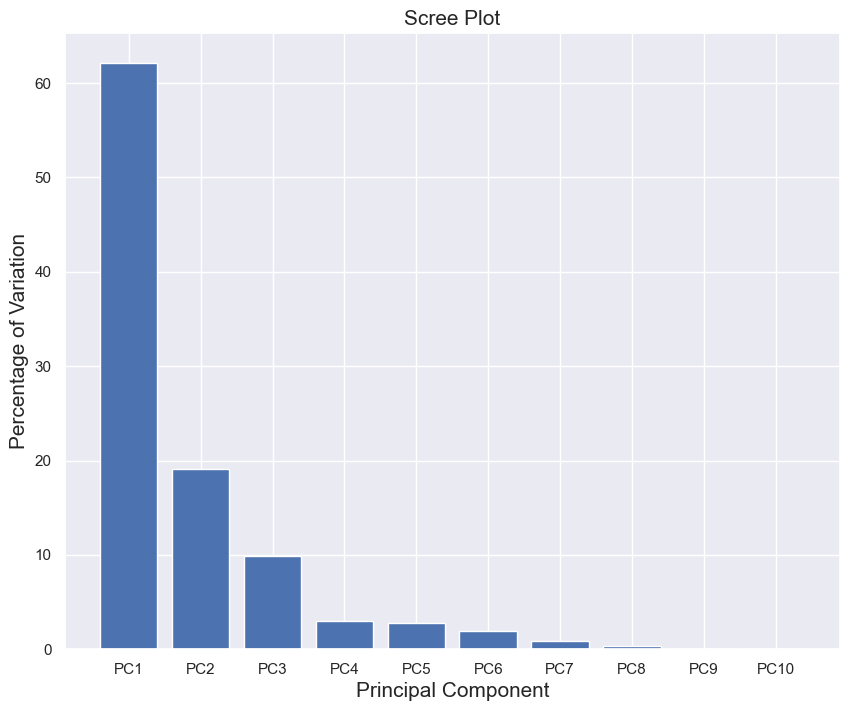

In [7]:
labels = [f"PC{i}" for i in range(1,11)]

plt.figure(figsize = (10, 8))
plt.bar(x = range(1, 11), height = per_var, tick_label = labels)
plt.xlabel('Principal Component', fontsize = 15)
plt.ylabel('Percentage of Variation', fontsize = 15)
plt.title('Scree Plot', fontsize = 15)
plt.show()

### Mapping Principal Components to Features
We show how each feature contributes to create each Principal Component. Each Principal Component is a linear combination of the original coordinates.

In [8]:
features = list(set(penguin_final.columns) - {'sex'})

pd.DataFrame(data = pca.components_, columns = labels, index = features)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.212482,-0.035738,0.248220,0.190700,-0.121950,-0.068750,3.963862e-01,-3.903436e-01,5.257986e-01,5.000418e-01
1,-0.188606,0.324135,-0.135529,-0.221493,0.286212,-0.064719,6.573035e-01,5.222160e-01,3.145287e-02,9.203768e-03
2,0.290407,-0.257951,-0.032456,0.073879,-0.226335,0.152456,-1.945288e-01,6.544935e-01,2.025520e-01,5.107962e-01
3,0.013593,-0.019899,0.006305,-0.368754,0.683025,-0.314272,-3.998383e-01,-6.726627e-02,2.493895e-01,2.674315e-01
4,-0.007348,0.019004,-0.011657,-0.580998,-0.099505,0.680503,-2.782364e-02,-1.100442e-01,3.828731e-01,-1.715510e-01
5,-0.050655,0.048819,0.001836,0.291182,-0.045095,-0.246087,-1.581395e-01,2.383931e-01,6.678004e-01,-5.655717e-01
flipper_length_mm,0.602424,-0.577701,-0.024722,-0.077474,0.183997,-0.106523,4.328113e-01,-1.217611e-01,5.960534e-02,-2.140730e-01
bill_length_mm,-0.368633,-0.396116,0.764749,-0.107034,0.079607,0.027426,-3.182681e-03,2.413897e-01,-1.523884e-01,-1.493748e-01
bill_depth_mm,0.576644,0.576644,0.576644,-0.028544,-0.028544,-0.028544,3.219562e-15,2.068865e-15,-2.888474e-15,-2.029844e-15
body_mass_g,0.028544,0.028544,0.028544,0.576644,0.576644,0.576644,-9.353754e-17,1.942631e-15,4.470273e-16,-1.937642e-15


### Visualizing Data in new Coordinate System

In [9]:
pca_data = pca.transform(X)

pca_df = pd.DataFrame(pca_data, columns = labels, index=penguin_final.index)

projected_df = pd.concat([pca_df, penguin_final.sex], axis = 1)
projected_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,sex
0,-2.002452,-0.407923,0.511655,-0.534349,0.392034,-0.679751,-0.102653,0.140781,2.775558e-15,1.110223e-16,Male
1,-1.496387,-0.693225,0.168820,-0.413433,0.588875,-0.645530,0.017537,-0.082781,4.440892e-16,-1.110223e-15,Female
2,-1.561350,-0.423642,0.120875,-0.515099,0.914799,0.220402,0.228566,-0.005406,1.110223e-15,9.992007e-16,Female
4,-2.031512,-0.513936,0.779958,-0.265080,0.762996,0.246150,-0.199052,0.140907,2.220446e-16,1.776357e-15,Female
5,-2.089173,0.139849,1.203692,-0.486873,0.552243,0.044622,-0.139500,0.294495,3.330669e-15,2.553513e-15,Male
...,...,...,...,...,...,...,...,...,...,...,...
338,2.268921,-0.776894,-0.618527,-0.039285,0.016898,-0.182626,0.078601,-0.056480,-3.330669e-16,-7.771561e-16,Female
340,2.111699,-0.664304,-0.437736,-0.037648,0.028718,0.002179,0.033970,0.020457,0.000000e+00,1.110223e-16,Female
341,2.917847,0.166903,0.573114,0.074954,-0.068502,-0.231414,0.022803,-0.053203,-1.110223e-16,-5.551115e-16,Male
342,2.001256,-0.726847,-0.035367,0.125364,-0.147867,-0.280222,-0.229781,0.050413,-7.771561e-16,-4.440892e-16,Female


In [10]:
def colors(y):
    if y == 'Male':
        return "red"
    else:
        return "lightseagreen"

c = [colors(label) for label in y]
projected_df['color'] = c
projected_df[['sex', 'color']]

,sex,color
0,Male,red
1,Female,lightseagreen
2,Female,lightseagreen
4,Female,lightseagreen
5,Male,red
...,...,...
338,Female,lightseagreen
340,Female,lightseagreen
341,Male,red
342,Female,lightseagreen


### Comparing Principal Comoponents
We compare the figures created by plotting Principal Component 1 VS Principal Component 2, and Principal Component 9 VS Principal Component 10.
Since PC1 and PC2 account for the most variance, the plot created by these two more effectively splits up the dataset than the plot of PC9 VS PC10

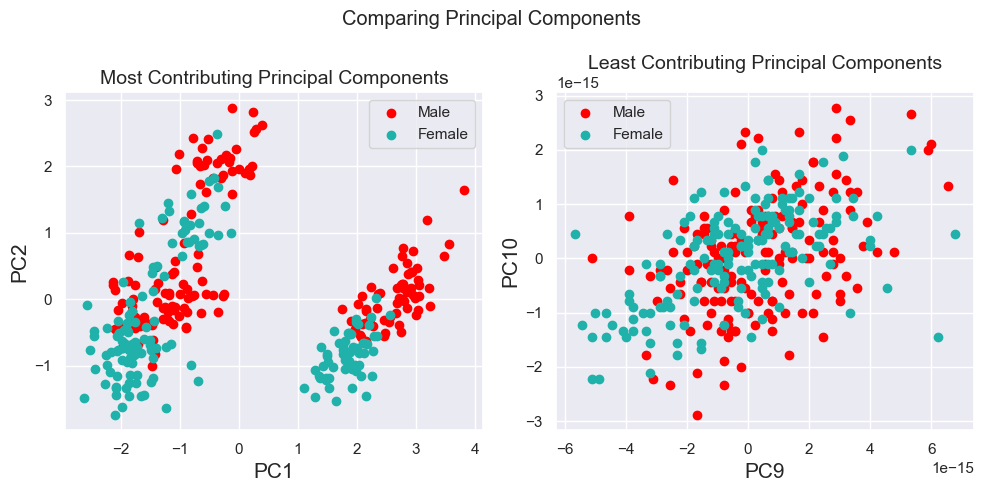

In [11]:
targets = ['Male', 'Female']
colors = ["red", "lightseagreen"]

fig, axes = plt.subplots(1,2, figsize=(10,5))

for target, color in zip(targets, colors):
    temp_df = projected_df[projected_df['sex'] == target]
    
    axes[0].scatter(temp_df["PC1"],
                temp_df["PC2"],
                c = color)
    
    axes[1].scatter(temp_df["PC9"],
                temp_df["PC10"],
                c = color)
    
    
axes[0].set_xlabel('PC1', fontsize = 15)
axes[0].set_ylabel('PC2', fontsize = 15)
axes[0].set_title('Most Contributing Principal Components', fontsize = 14)
axes[0].legend(targets)

axes[1].set_xlabel('PC9', fontsize = 15)
axes[1].set_ylabel('PC10', fontsize = 15)
axes[1].set_title('Least Contributing Principal Components', fontsize = 14)
axes[1].legend(targets)

plt.suptitle('Comparing Principal Components')
plt.tight_layout()
plt.show()